## Dataset

1. We use the Bank Marketing Dataset from the UCI Machine Learning Repository.
Source: https://archive.ics.uci.edu/ml/datasets/bank+marketing

2. The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. Originally designed for supervised learning, but we will ignore the label initially

Important Decision:

Even though the dataset contains subscribed (whether the client subscribed to a term deposit), we do not use it to train the clustering model.
We may, however, use it later for interpretation only.

    # bank client data:
    1 - age (numeric)
    2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
    3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
    4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
    5 - default: has credit in default? (categorical: 'no','yes','unknown')
    6 - housing: has housing loan? (categorical: 'no','yes','unknown')
    7 - loan: has personal loan? (categorical: 'no','yes','unknown')
    # related with the last contact of the current campaign:
    8 - contact: contact communication type (categorical: 'cellular','telephone')
    9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
    10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
    11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
    # other attributes:
    12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
    13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
    14 - previous: number of contacts performed before this campaign and for this client (numeric)
    15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
    # social and economic context attributes
    16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
    17 - cons.price.idx: consumer price index - monthly indicator (numeric)
    18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
    19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
    20 - nr.employed: number of employees - quarterly indicator (numeric)
    21 - y - has the client subscribed a term deposit? (binary: 'yes','no')

## task 1

### Requirements

The goal of this lab is to **explore the bank dataset, prepare it for clustering, and apply K-Means**.  
Follow these steps carefully and write down your observations.  

### **Exploratory Data Analysis (EDA)** (understanding the dataset and its characteristics)

For each feature, you should:

- Identify **numeric vs categorical features**  
- Check **distributions** of numeric features (min, max, mean, std, skewness)  
- Check **counts of categories** for categorical features  
- Identify **missing or unknown values** and decide how to handle them  
- Look for **correlations** between numeric features  
- Identify **outliers** that may affect clustering  

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('bank-additional-full.csv', sep=';')
df = df.copy()

In [2]:
df.info()

# Separating numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [3]:
# Check distribution & skew of numeric columns
for col in numeric_cols:
    print(f"Distribution of {col}:")
    print(df[col].describe())
    print(f"Skewness: {df[col].skew()}")
    print("\n")

Distribution of age:
count    41188.00000
mean        40.02406
std         10.42125
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64
Skewness: 0.7846968157646645


Distribution of duration:
count    41188.000000
mean       258.285010
std        259.279249
min          0.000000
25%        102.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64
Skewness: 3.263141255262832


Distribution of campaign:
count    41188.000000
mean         2.567593
std          2.770014
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
Name: campaign, dtype: float64
Skewness: 4.762506697067009


Distribution of pdays:
count    41188.000000
mean       962.475454
std        186.910907
min          0.000000
25%        999.000000
50%        999.000000
75%        999.000000
max        999.000000
Name: pdays, dtype: float64
S

In [4]:
# Ckeck counts of categorical columns
for col in categorical_cols:
    print(f"Value counts of {col}:")
    print(df[col].value_counts())
    print("\n")

Value counts of job:
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64


Value counts of marital:
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64


Value counts of education:
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64


Value counts of default:
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64


Value counts of housing:
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64


Value counts of l

In [5]:
# Identify missing or unknown values and handle them appropriately
for col in df.columns:
    missing_count = df[col].isnull().sum()
    unknown_count = (df[col] == 'unknown').sum()
    print(f"{col}: Missing={missing_count}, Unknown={unknown_count}")
df.replace("unknown", pd.NA, inplace=True)
df[categorical_cols] = df[categorical_cols].fillna("Missing")
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

age: Missing=0, Unknown=0
job: Missing=0, Unknown=330
marital: Missing=0, Unknown=80
education: Missing=0, Unknown=1731
default: Missing=0, Unknown=8597
housing: Missing=0, Unknown=990
loan: Missing=0, Unknown=990
contact: Missing=0, Unknown=0
month: Missing=0, Unknown=0
day_of_week: Missing=0, Unknown=0
duration: Missing=0, Unknown=0
campaign: Missing=0, Unknown=0
pdays: Missing=0, Unknown=0
previous: Missing=0, Unknown=0
poutcome: Missing=0, Unknown=0
emp.var.rate: Missing=0, Unknown=0
cons.price.idx: Missing=0, Unknown=0
cons.conf.idx: Missing=0, Unknown=0
euribor3m: Missing=0, Unknown=0
nr.employed: Missing=0, Unknown=0
y: Missing=0, Unknown=0


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\nouna\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Correlation Matrix:
                     age  duration  campaign     pdays  previous  \
age             1.000000 -0.000866  0.004594 -0.034369  0.024365   
duration       -0.000866  1.000000 -0.071699 -0.047577  0.020640   
campaign        0.004594 -0.071699  1.000000  0.052584 -0.079141   
pdays          -0.034369 -0.047577  0.052584  1.000000 -0.587514   
previous        0.024365  0.020640 -0.079141 -0.587514  1.000000   
emp.var.rate   -0.000371 -0.027968  0.150754  0.271004 -0.420489   
cons.price.idx  0.000857  0.005312  0.127836  0.078889 -0.203130   
cons.conf.idx   0.129372 -0.008173 -0.013733 -0.091342 -0.050936   
euribor3m       0.010767 -0.032897  0.135133  0.296899 -0.454494   
nr.employed    -0.017725 -0.044703  0.144095  0.372605 -0.501333   

                emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  \
age                -0.000371        0.000857       0.129372   0.010767   
duration           -0.027968        0.005312      -0.008173  -0.032897   
campaign 

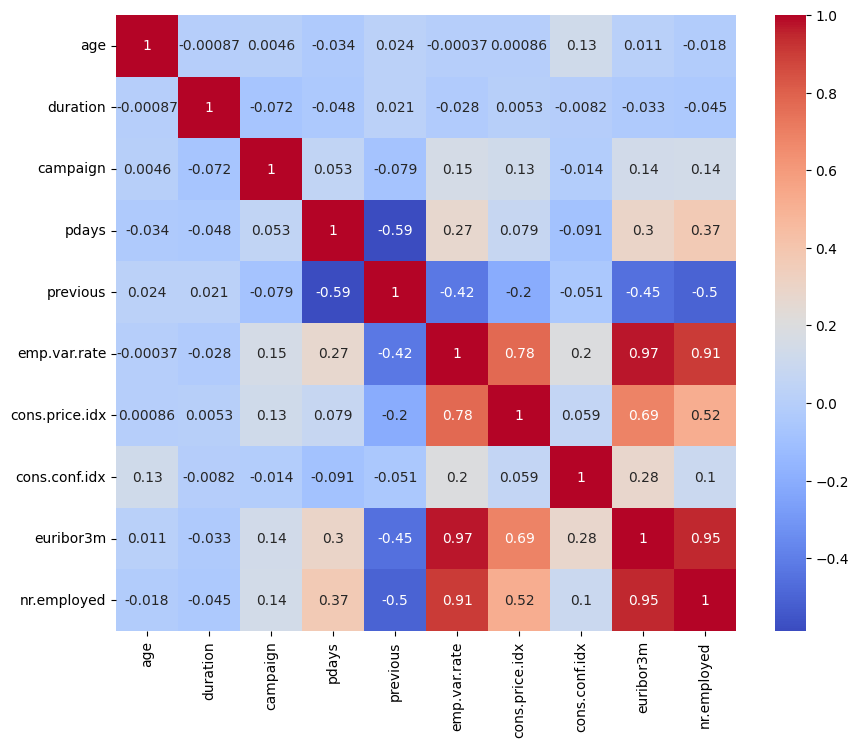

In [6]:
# Install missing package and perform correlation analysis for numeric columns
%pip install seaborn
        
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df[numeric_cols].corr()
print("Correlation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.show()


In [7]:
# Identify outliers in numeric columns using iQR method
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Outliers in {col}:")
    print(outliers[[col]])
    print("\n")

Outliers in age:
       age
27713   70
27757   76
27780   73
27800   88
27802   88
...    ...
40986   84
40996   81
41004   80
41183   73
41187   74

[469 rows x 1 columns]


Outliers in duration:
       duration
37         1666
57          787
61          812
75         1575
83         1042
...         ...
41147       712
41153       655
41160       843
41164      1868
41166       651

[2963 rows x 1 columns]


Outliers in campaign:
       campaign
887           7
1043          8
1094          8
1097          7
1230          7
...         ...
40611         9
40631         7
40698         7
40821         9
40993         7

[2406 rows x 1 columns]


Outliers in pdays:
       pdays
24108      6
24264      4
24279      4
24397      3
24482      4
...      ...
41163      4
41164     10
41174      1
41178      6
41182      9

[1515 rows x 1 columns]


Outliers in previous:
       previous
24013         1
24019         1
24076         1
24102         1
24108         1
...         ...
41174  

### **Data Preparation**

Before applying K-Means:

- Drop irrelevant or target columns
- Encode categorical features into numeric format
- Scale numeric features so all are comparable for distance calculations  
- Check that the final dataset has **no missing values** and **all features are numeric**  

In [8]:
# Drop target column
df.drop('y', axis=1, inplace=True)
categorical_cols = categorical_cols.drop('y')

In [9]:
# Perform One-Hot Encoding for categorical variables
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


In [ ]:
# Scale numeric features so all are comparable
from sklearn.preprocessing import StandardScaler    
scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

In [10]:
# Check that the final data has no missing values & all features are numeric
print("Final Data Info:")
print(df_encoded.info())


Final Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            41188 non-null  int64  
 1   duration                       41188 non-null  int64  
 2   campaign                       41188 non-null  int64  
 3   pdays                          41188 non-null  int64  
 4   previous                       41188 non-null  int64  
 5   emp.var.rate                   41188 non-null  float64
 6   cons.price.idx                 41188 non-null  float64
 7   cons.conf.idx                  41188 non-null  float64
 8   euribor3m                      41188 non-null  float64
 9   nr.employed                    41188 non-null  float64
 10  job_admin.                     41188 non-null  bool   
 11  job_blue-collar                41188 non-null  bool   
 12  job_entrepreneur             

### **Apply K-Means Clustering**

- Decide an initial number of clusters (K)  
- Fit the K-Means model to your prepared dataset  
- Assign each data point to a cluster

In [11]:
# Decide an initial number of cluters K
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)


In [12]:
# fit the KMeans model to the data
cluster_labels = kmeans.fit(df_encoded)


In [13]:
# Assign each data point to its respective cluster
df_encoded['Cluster'] = cluster_labels

### **Choosing the Convenient K**

- Use **Elbow Method**: plot Sum of Squared Distances (SSD) vs K  
- Identify the **elbow point** where SSD reduction slows  
- Calculate **Silhouette scores** to validate K  

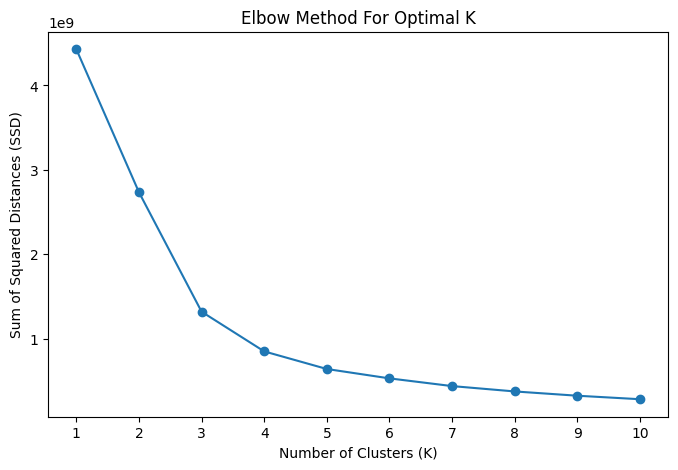

In [14]:
# Use Elbow method to plot SSD vs K
ssd = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(df_encoded.drop('Cluster', axis=1))
    ssd.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(K_range, ssd, marker='o')  
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Distances (SSD)')
plt.title('Elbow Method For Optimal K')
plt.xticks(K_range)
plt.show()


The Elbow point where the SSD reduction slows is at K = 3

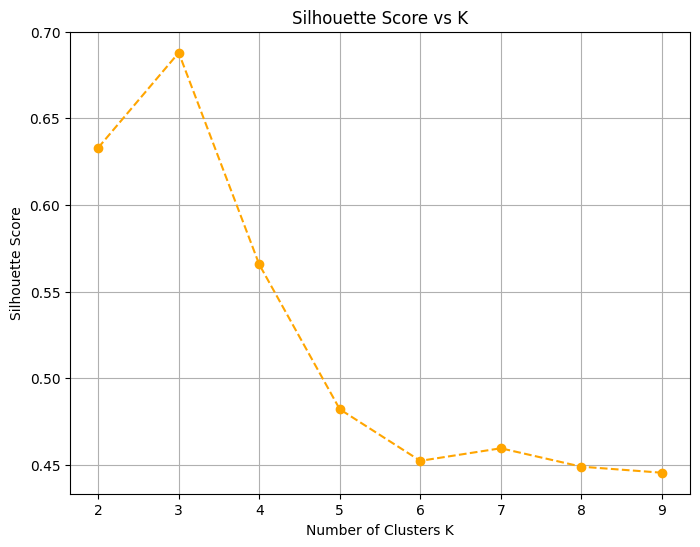

In [17]:
# Calculate silhouette score to validate K
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    # fit K-Means and assign each point to a cluster
    labels = km.fit_predict(df_encoded.drop('Cluster', axis=1))

    # average Silhouette Score for all points
    score = silhouette_score(df_encoded.drop('Cluster', axis=1), labels)

    sil_scores.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(8,6))
plt.plot(range(2,10), sil_scores, 'o--', color='orange')
plt.xlabel("Number of Clusters K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.grid(True)
plt.show()
